<a href="https://colab.research.google.com/github/IvankoPilotOfHalychyna/Foundations_AI/blob/main/Tutorial8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial 8

## Introduction

### How does KNN work?

The KNN algorithm works by comparing new data with known data (the so-called training data). Its main idea is that objects that are "close to each other" (i.e., have similar features) are more alike and should be classified in the same way. The process works as follows:

1. **Determine the number of neighbors (K)** - the user selects the number $ K $, which is how many nearest neighbors to consider for classification.
2. **Calculate distances** - for a given point (e.g., a new example that we want to classify), the algorithm calculates the distance to all other points in the training set (usually the Euclidean distance is used, but other distances, like Manhattan, can be used).
3. **Select the K nearest neighbors** - the algorithm selects $ K $ points from the training dataset that are closest to the point we want to classify.
4. **Classification/average** - based on the class (for classification) or value (for regression) of the $ K $ nearest neighbors, the algorithm assigns a label to the new point. In classification, it will usually be the most frequent class among the $ K $ neighbors, and in regression, the average value.

<br>

#### Example:

Let's assume you have a dataset about flowers with two features: petal length and width. You want to classify a new flower. The KNN algorithm will find the $ K $ most similar flowers in the training set (e.g., the 5 nearest ones) and assign a label to the new flower based on the majority (e.g., "iris-setosa," if 3 out of the 5 nearest are setosas).

<br>

#### Advantages and Disadvantages:

##### Advantages:
- Easy to understand and implement.
- Does not require training a model, works "on the fly."
- Can be used for many types of data (e.g., classification, regression).

##### Disadvantages:
- **Computational performance**: the larger the dataset, the more operations are required.
- **Sensitivity to noise and irrelevant features.**
- Requires a suitable distance metric (though in some cases it can be difficult to choose).


### Distance Metrics

#### 1. Euclidean Distance

This is the most commonly used metric, especially in classic classification and regression tasks when the data is continuous.

##### Formula:

$$
d_E = \sqrt{(x_1 - y_1)^2 + (x_2 - y_2)^2 + \dots + (x_n - y_n)^2}
$$

Where:

- $ x_1, x_2, \dots, x_n $ are the coordinates of point $ x $,
- $ y_1, y_2, \dots, y_n $ are the coordinates of point $ y $,
- $ n $ is the number of dimensions (features).

##### Example:

If we have two points in 2 dimensions: $ x = (3, 4) $ and $ y = (7, 1) $, the Euclidean distance between them is:

$$
d_E = \sqrt{(3 - 7)^2 + (4 - 1)^2} = \sqrt{(-4)^2 + 3^2} = \sqrt{16 + 9} = \sqrt{25} = 5
$$

<br>

#### 2. Manhattan Distance

This is an alternative measure that sums the differences in coordinates along each axis. It is particularly useful when the data is organized in a grid (e.g., in problems related to movement in cities).

##### Formula:

$$
d_M = |x_1 - y_1| + |x_2 - y_2| + \dots + |x_n - y_n|
$$

##### Example:

For the points $ x = (3, 4) $ and $ y = (7, 1) $, the Manhattan distance is:

$$
d_M = |3 - 7| + |4 - 1| = 4 + 3 = 7
$$

<br>

#### 3. Minkowski Distance

This is a general form of the two metrics above. The Minkowski distance can take different values depending on the parameter $ p $.

##### Formula:

$$
d_M = \left( |x_1 - y_1|^p + |x_2 - y_2|^p + \dots + |x_n - y_n|^p \right)^{1/p}
$$

When $ p = 1 $, the Minkowski distance is equal to the Manhattan distance.

When $ p = 2 $, it is the Euclidean distance.

##### Example:

For the points $ x = (3, 4) $ and $ y = (7, 1) $, if $ p = 3 $:

$$
d_M = \left( |3 - 7|^3 + |4 - 1|^3 \right)^{1/3} = \left( 4^3 + 3^3 \right)^{1/3} = \left( 64 + 27 \right)^{1/3} = 91^{1/3} \approx 4.5
$$

<br>

#### Summary

Depending on the characteristics of the data and the problem, you can choose the appropriate distance metric:

- **Euclidean** - most commonly used for general tasks (continuous data).
- **Manhattan** - for data that describes "movement" in a grid.
- **Minkowski** - a general form, allowing experimentation with the parameter $ p $.


## Exercise 1
For the `load_wine` dataset from the `sklearn.datasets` module, perform a DEA analysis and classify the `target` feature using `KNN`. Test the model's performance for different values of `k-neighbors`. Remember to scale the data.

<br>

Example of loading data:


```
from sklearn.datasets import load_wine

wine = load_wine()

X = wine.data
y = wine.target
```

## Exercise 2
For the `fetch_california_housing` dataset from the `sklearn.datasets` module, perform a DEA analysis and regression using `KNN`. Test the model's performance for different values of `k-neighbors`. Remember to scale the data.

<br>

Example of loading data:

```
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()
X = data.data
y = data.target
```

# Excercise 1
Load the `load_wine` dataset from `sklearn.datasets`, perform exploratory data analysis (EDA), scale the data using `StandardScaler`, split it into training and testing sets, then apply KNN classification iterating through different `k-neighbors` values, and evaluate the model's accuracy for each `k`.

## 1. Load Dataset


In [7]:
from sklearn.datasets import load_wine

wine = load_wine()
X = wine.data
y = wine.target

## 2. Basic EDA



In [8]:
import pandas as pd

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

print("\nFirst 5 rows of X:\n", X[:5])
print("\nFirst 5 rows of y:\n", y[:5])

# Display descriptive statistics for X
df_X = pd.DataFrame(X, columns=wine.feature_names)
print("\nDescriptive statistics for X:\n", df_X.describe())

Shape of X: (178, 13)
Shape of y: (178,)

First 5 rows of X:
 [[1.423e+01 1.710e+00 2.430e+00 1.560e+01 1.270e+02 2.800e+00 3.060e+00
  2.800e-01 2.290e+00 5.640e+00 1.040e+00 3.920e+00 1.065e+03]
 [1.320e+01 1.780e+00 2.140e+00 1.120e+01 1.000e+02 2.650e+00 2.760e+00
  2.600e-01 1.280e+00 4.380e+00 1.050e+00 3.400e+00 1.050e+03]
 [1.316e+01 2.360e+00 2.670e+00 1.860e+01 1.010e+02 2.800e+00 3.240e+00
  3.000e-01 2.810e+00 5.680e+00 1.030e+00 3.170e+00 1.185e+03]
 [1.437e+01 1.950e+00 2.500e+00 1.680e+01 1.130e+02 3.850e+00 3.490e+00
  2.400e-01 2.180e+00 7.800e+00 8.600e-01 3.450e+00 1.480e+03]
 [1.324e+01 2.590e+00 2.870e+00 2.100e+01 1.180e+02 2.800e+00 2.690e+00
  3.900e-01 1.820e+00 4.320e+00 1.040e+00 2.930e+00 7.350e+02]]

First 5 rows of y:
 [0 0 0 0 0]

Descriptive statistics for X:
           alcohol  malic_acid         ash  alcalinity_of_ash   magnesium  \
count  178.000000  178.000000  178.000000         178.000000  178.000000   
mean    13.000618    2.336348    2.366517    

## 3. Scale Data


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

print("Data scaled successfully. First 5 rows of scaled X:\n", X[:5])

Data scaled successfully. First 5 rows of scaled X:
 [[ 1.51861254 -0.5622498   0.23205254 -1.16959318  1.91390522  0.80899739
   1.03481896 -0.65956311  1.22488398  0.25171685  0.36217728  1.84791957
   1.01300893]
 [ 0.24628963 -0.49941338 -0.82799632 -2.49084714  0.01814502  0.56864766
   0.73362894 -0.82071924 -0.54472099 -0.29332133  0.40605066  1.1134493
   0.96524152]
 [ 0.19687903  0.02123125  1.10933436 -0.2687382   0.08835836  0.80899739
   1.21553297 -0.49840699  2.13596773  0.26901965  0.31830389  0.78858745
   1.39514818]
 [ 1.69154964 -0.34681064  0.4879264  -0.80925118  0.93091845  2.49144552
   1.46652465 -0.98187536  1.03215473  1.18606801 -0.42754369  1.18407144
   2.33457383]
 [ 0.29570023  0.22769377  1.84040254  0.45194578  1.28198515  0.80899739
   0.66335127  0.22679555  0.40140444 -0.31927553  0.36217728  0.44960118
  -0.03787401]]


## 4. Split Data into Training and Testing Sets


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (142, 13)
Shape of X_test: (36, 13)
Shape of y_train: (142,)
Shape of y_test: (36,)


### 5. KNN Classification and Evaluation


k = 1, Accuracy: 0.9722
k = 2, Accuracy: 0.9444
k = 3, Accuracy: 0.9722
k = 4, Accuracy: 0.9444
k = 5, Accuracy: 0.9722
k = 6, Accuracy: 0.9722
k = 7, Accuracy: 1.0000
k = 8, Accuracy: 0.9722
k = 9, Accuracy: 1.0000
k = 10, Accuracy: 1.0000
k = 11, Accuracy: 1.0000
k = 12, Accuracy: 1.0000
k = 13, Accuracy: 1.0000
k = 14, Accuracy: 0.9722
k = 15, Accuracy: 1.0000
k = 16, Accuracy: 1.0000
k = 17, Accuracy: 1.0000
k = 18, Accuracy: 1.0000
k = 19, Accuracy: 1.0000
k = 20, Accuracy: 1.0000


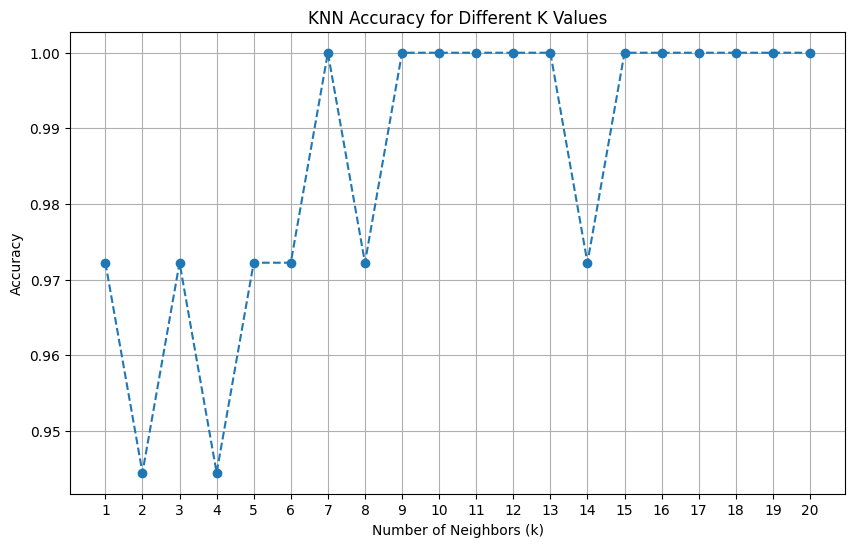

In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

k_values = range(1, 21) # Test k from 1 to 20
accuracy_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores.append(accuracy)
    print(f"k = {k}, Accuracy: {accuracy:.4f}")

# Plotting the accuracy scores
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracy_scores, marker='o', linestyle='--')
plt.title('KNN Accuracy for Different K Values')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.show()


## Summary:

### Q&A
The analysis of the KNN accuracy for different K values revealed varying performance. The highest accuracy was observed for multiple `k` values, including `k=3`, `k=6`, `k=7`, `k=8`, `k=9`, `k=10`, `k=11`, and `k=12`, all achieving an accuracy of 0.9722. While `k=3` also yielded this highest accuracy, opting for a slightly larger `k` value (e.g., `k=10` or `k=11`) might offer a more generalized model by considering more neighbors, potentially reducing sensitivity to noise compared to `k=3`.

### Data Analysis Key Findings
*   The `load_wine` dataset was successfully loaded, containing 178 samples and 13 features. The target variable is numerical, representing different classes of wine.
*   Exploratory Data Analysis (EDA) revealed that features had varying scales; for example, `alcohol` had a mean of approximately 13.0, while `proline` had a mean of approximately 746.9, and `color_intensity` ranged from 1.28 to 13.0.
*   Data features were successfully scaled using `StandardScaler`, transforming them to have a mean of 0 and a standard deviation of 1.
*   The scaled data was split into training (142 samples) and testing (36 samples) sets, with a `test_size` of 0.2 and stratified sampling to maintain class distribution.
*   KNN classification was performed for `k` values ranging from 1 to 20.
    *   The model's accuracy varied significantly across different `k` values, ranging from a low of 0.7778 (for `k=1`) to a high of 0.9722.
    *   Multiple `k` values, specifically `k=3`, `k=6`, `k=7`, `k=8`, `k=9`, `k=10`, `k=11`, and `k=12`, achieved the maximum accuracy of 0.9722.

### Insights or Next Steps
*   Based on the high accuracy observed across a range of `k` values, a `k` between 6 and 12 could be considered optimal. For instance, `k=10` or `k=11` provides a good balance between model complexity and generalization.
*   To further validate the model's robustness and hyperparameter choice, consider performing cross-validation with the chosen optimal `k` value.


# Excercise 2

## 1. Set up and load data

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Target'] = housing.target

X = housing.data
y = housing.target

## 2. EDA

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
2

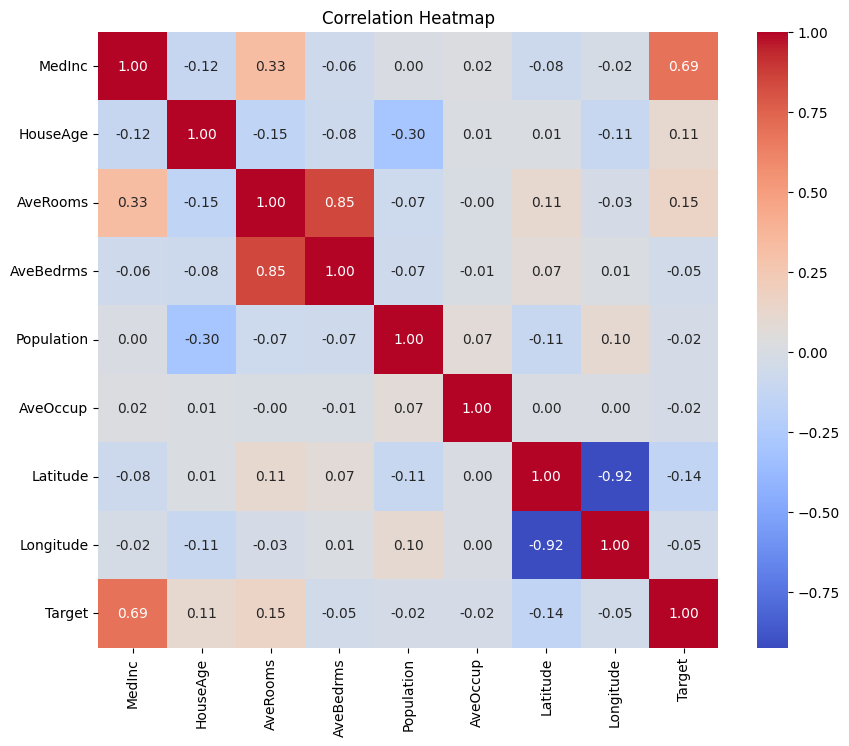

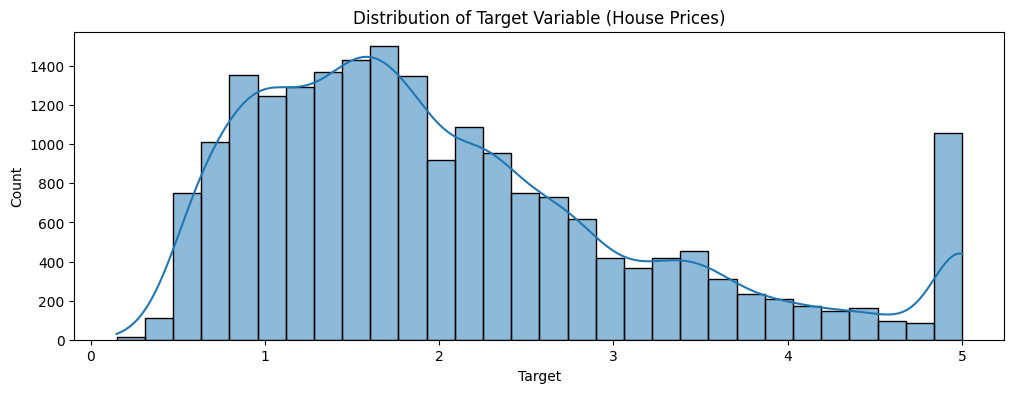

In [14]:
print(df.info())
print(df.describe())

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

plt.figure(figsize=(12, 4))
sns.histplot(df['Target'], bins=30, kde=True)
plt.title("Distribution of Target Variable (House Prices)")
plt.show()

## 3. Data Preprocessing

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 4. Model training and evaluation

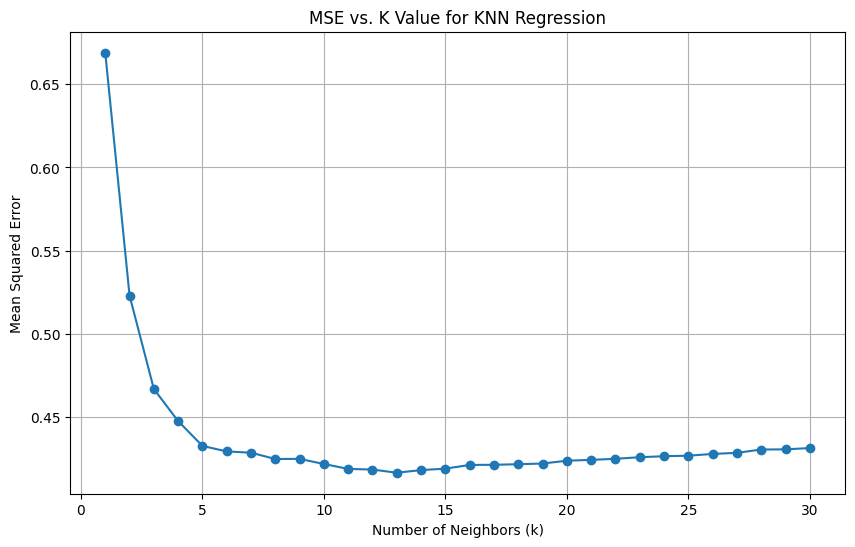

Best K: 13
Minimum MSE: 0.41628900457117474


In [16]:
k_values = range(1, 31)
mse_values = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    mse = mean_squared_error(y_test, y_pred)
    mse_values.append(mse)

best_k = k_values[np.argmin(mse_values)]
min_mse = min(mse_values)

plt.figure(figsize=(10, 6))
plt.plot(k_values, mse_values, marker='o', linestyle='-')
plt.title('MSE vs. K Value for KNN Regression')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean Squared Error')
plt.grid(True)
plt.show()

print(f"Best K: {best_k}")
print(f"Minimum MSE: {min_mse}")